# Amazon US Customer Reviews: Preprocessing & First Distributed Model

This notebook explores the data in the [Amazon US Customer Reviews](https://www.kaggle.com/datasets/cynthiarempel/amazon-us-customer-reviews-dataset) dataset sourced from Kaggle. 

## Setup and Imports

In [1]:
from pyspark.sql import SparkSession, SQLContext
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
from pyspark.sql import SQLContext
from pyspark.sql.functions import col, length, round, expr, sum as spark_sum
from pyspark.ml.feature import Imputer, StringIndexer, VectorAssembler
import builtins
py_round = builtins.round

Matplotlib created a temporary cache directory at /scratch/kzhu8/job_49125127/matplotlib-zottkaz2 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Spark Session Configuration

Our SDSC Expanse allocation provides 16 total cores and 128 GB total memory. The dataset is 50.68 GB across 37 Parquet files. 

In [2]:
import subprocess, os
USER = os.getenv("USER")
subprocess.run(["mkdir", "-p", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp"])

CompletedProcess(args=['mkdir', '-p', '/expanse/lustre/projects/uci157/kzhu8/spark_tmp'], returncode=0)

In [3]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config('spark.executor.instances', 15) \
    .config("spark.executor.cores", "1") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.local.dir", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp") \
    .config("spark.sql.parquet.columnarReaderBatchSize", "128") \
    .getOrCreate()

### Executor Verification

In [4]:
# Get the active Spark Context, URL, and SQL Context
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"
sqlContext = SQLContext(spark.sparkContext)

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
spd = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
spd['maxMemory_GB'] = (spd['maxMemory'] / (1024**3)).round(2)
spd

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,16,4965217075,0,True,4.62


### Current Spark Configuration

In [5]:
print("Executor Instances:", sc.getConf().get("spark.executor.instances"))
print("Executor Memory:", sc.getConf().get("spark.executor.memory"))
print("Driver Memory:", sc.getConf().get("spark.driver.memory"))
print("Executor Cores:", sc.getConf().get("spark.executor.cores"))
print("Total Cores Available:", sc._jsc.sc().defaultParallelism())

Executor Instances: 15
Executor Memory: 8g
Driver Memory: 100g
Executor Cores: 1
Total Cores Available: 16


## Data Loading

In [6]:
# Load the data into Spark dataframe
parquet_path = r"/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews.parquet"
df = spark.read.parquet(parquet_path)

## 1. Complete Preprocessing using Spark

### 1) Clean below invalid data
1. Product category has invalid data like dates and reviews.
2. Star ratings has Null and dates
3. Null records in "review_id", "review_body", "review_headline", "review_date" and "product_category"
4. Duplicate review ids. Reviews have to be unique for analysis

In [7]:
def filter_invalid_categories(df):
    valid_categories = [
        "Wireless", "PC", "Mobile_Apps", "Digital_Ebook_Pur...", "Video DVD",
        "Apparel", "Music", "Health & Personal...", "Beauty", "Digital_Video_Dow...",
        "Toys", "Sports", "Shoes", "Books", "Automotive", "Electronics",
        "Office Products", "Pet Products", "Grocery", "Outdoors", "Camera",
        "Video Games", "Digital_Music_Pur...", "Baby", "Tools", "Watches",
        "Musical Instruments", "Furniture", "Video", "Software", "Gift Card",
        "Digital_Video_Games", "Mobile_Electronics", "Digital_Software",
        "Major Appliances", "Personal_Care_App...", "Home Entertainment",
        "Home Improvement", "Home", "Kitchen", "Lawn and Garden", "Luggage"
    ]
    return df.filter(col("product_category").isin(valid_categories))


def filter_invalid_star_ratings(df):
    valid_ratings = [1, 2, 3, 4, 5]
    return df.withColumn("star_rating", col("star_rating").cast("int")) \
             .withColumn("helpful_votes", col("helpful_votes").cast("int")) \
             .withColumn("total_votes", col("total_votes").cast("int")) \
             .filter(col("star_rating").isin(valid_ratings))


def drop_null_records(df):
    required_columns = ["review_id", "review_body", "review_headline", "review_date", "product_category"]
    return df.dropna(subset=required_columns)


def drop_duplicate_reviews(df):
    return df.dropDuplicates(["review_id"])

def impute_missing_values(df):
    imputer = Imputer(
        strategy="median",
        inputCols=["star_rating", "helpful_votes", "total_votes"],
        outputCols=["star_rating", "helpful_votes", "total_votes"]
    )
    return imputer.fit(df).transform(df)

In [8]:
def cleansing1(df):
    df = filter_invalid_categories(df)
    df = filter_invalid_star_ratings(df)
    df = drop_null_records(df)
    df = drop_duplicate_reviews(df)
    df = impute_missing_values(df)
    return df

### 2) Numerical Encoding

- Cast star_rating from String to Integer for numerical processing. (Just in case we calculate the mean or so)
- Apply StringIndexer to encode categorical variables (e.g., verified_purchase) into binary (0/1).

In [9]:
def cleansing2(df):
    df = df.withColumn("star_rating", col("star_rating").cast("int"))
    df = df.withColumn("review_headline_length", length(col("review_headline")))
    
    indexer_vp = StringIndexer(inputCol="verified_purchase", outputCol="verified_purchase_idx", handleInvalid="keep")
    df = indexer_vp.fit(df).transform(df)
    
    category_indexer = StringIndexer(
        inputCol="product_category", outputCol="category_idx", handleInvalid="keep"
    )
    df = category_indexer.fit(df).transform(df)

    return df

### 3) Text Analytics & Scaling

- Compute review_length using the length() function on the review_body column.
- Implement StandardScaler or MinMaxScaler to normalize numerical features for better model convergence.
- (Optional) Prepare a Tokenizer for potential text-based model expansion in Milestone 4.

In [10]:
from pyspark.ml.feature import MinMaxScaler, Tokenizer

def cleansing3(df):
    df = df.withColumn("review_length", length(col("review_body")))    
    tokenizer = Tokenizer(inputCol="review_body", outputCol="review_tokens")
    df = tokenizer.transform(df)

    return df

### 4) Target Engineering & Sampling

- Calculate the target variable: `helpfulness_ratio` (helpful_votes / total_votes) for rows where total_votes > 0
- Create other new features using Spark SQL functions (e.g., log of review length)
- Implement sampleBy() for Stratified Sampling to address the heavy skew toward 5-star ratings

In [11]:
from pyspark.sql.functions import when, log1p

def cleansing4(df):
    # Target variable
    df = df.filter(col("total_votes") > 0)
    df = df.withColumn("helpfulness_ratio", col("helpful_votes") / col("total_votes"))
    df = df.withColumn("label",
        when(col("helpful_votes") / col("total_votes") >= 0.5, 1.0).otherwise(0.0))
    
    # Feature engineering using Spark SQL functions
    df = df.withColumn("log_helpful_votes", log1p(col("helpful_votes")))
    df = df.withColumn("log_total_votes", log1p(col("total_votes")))
    df = df.withColumn("log_review_length", log1p(col("review_length")))

    # Stratified Sampling
    fractions = {1: 0.6, 2: 1.0, 3: 0.67, 4: 0.32, 5: 0.09}
    df = df.sampleBy("star_rating", fractions=fractions, seed=42)
    return df

### Pipelines

In [12]:
# df_clean.write.mode("overwrite").parquet("/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet")

In [ ]:
#=== df_clean is stored in "/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet". No need to run this cell ===
checkpoint_dir = "/expanse/lustre/projects/uci157/hkwon2/spark_checkpoints"
spark.sparkContext.setCheckpointDir(checkpoint_dir)

df_clean = cleansing4(cleansing3(cleansing2(cleansing1(df)))).checkpoint()

### Output of preprocessed clean dataset

In [12]:
output_path = "/expanse/lustre/projects/uci157/hkwon2/shared/amazon_reviews_clean.parquet"
df_clean = spark.read.parquet(output_path)

In [13]:
df_count = df.count()
df_clean_count = df_clean.count()

print(f"Before preprocessing: {df_count}")
print(f"After preprocessing: {df_clean_count}")
print(f"{100*(df_count-df_clean_count)/df_count:.2f}% reduction in rows.")

Before preprocessing: 109830520
After preprocessing: 11405130
89.62% reduction in rows.


The reduction in rows is due to noise removal (invalid categories, bad star ratings, nulls, duplicates), filtering out reviews that had a total vote equal to 0, and stratified sampling (downsample data to balance star rating classes).

In [14]:
df_clean.select("label").groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|3330981|
|  1.0|8074149|
+-----+-------+



Label 1 is about 2.4 times larger than the other. When measuring accuracy, AUC and F1 scoring will have to be used to evaluate it, considering the imbalance of data.

In [15]:
# View the schema
df_clean.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_headline_length: integer (nullable = true)
 |-- verified_purchase_idx: double (nullable = true)
 |-- category_idx: double (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- review_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- helpfulness_ratio: double (nullable = tr

## 2. Train Your First Distributed Model

### Feature Assembly & Train/Val/Test Split

In [16]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

feature_cols = [
    "star_rating",
    "log_review_length",
    "review_headline_length",
    "verified_purchase_idx",
    "category_idx"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

train_df, val_df, test_df = df_clean.randomSplit([0.7, 0.15, 0.15], seed=42)

### Model 0: Logistic Regression (Baseline)

In [17]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StandardScaler
from pyspark.ml import Pipeline

assembler_lr = VectorAssembler(inputCols=feature_cols, outputCol="raw_features", handleInvalid="skip")
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20, regParam=0.01)
pipeline_lr = Pipeline(stages=[assembler_lr, scaler, lr])
model_lr = pipeline_lr.fit(train_df)

train_pred_lr = model_lr.transform(train_df).cache()
val_pred_lr = model_lr.transform(val_df).cache()
test_pred_lr = model_lr.transform(test_df).cache()
train_pred_lr.count()
val_pred_lr.count()
test_pred_lr.count()

lr_results = {
    "Model": "Logistic Regression (Baseline)",
    "Train AUC": py_round(evaluator_auc.evaluate(train_pred_lr), 4),
    "Val AUC": py_round(evaluator_auc.evaluate(val_pred_lr), 4),
    "Test AUC": py_round(evaluator_auc.evaluate(test_pred_lr), 4),
    "Train F1": py_round(evaluator_f1.evaluate(train_pred_lr), 4),
    "Val F1": py_round(evaluator_f1.evaluate(val_pred_lr), 4),
    "Test F1": py_round(evaluator_f1.evaluate(test_pred_lr), 4),
}

print("=== Logistic Regression (Baseline) ===")
print(f"Train AUC: {lr_results['Train AUC']} | F1: {lr_results['Train F1']}")
print(f"Val   AUC: {lr_results['Val AUC']}   | F1: {lr_results['Val F1']}")
print(f"Test  AUC: {lr_results['Test AUC']}  | F1: {lr_results['Test F1']}")

=== Logistic Regression (Baseline) ===
Train AUC: 0.6623 | F1: 0.6364
Val   AUC: 0.6628   | F1: 0.6373
Test  AUC: 0.6633  | F1: 0.636


### Model 1: Random Forest (numTrees=20 and maxDepth=15)

In [36]:
from pyspark.ml.classification import RandomForestClassifier
import time 

rf_model1 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxDepth=15, maxBins=64, seed=42)
pipeline_rf_model1 = Pipeline(stages=[assembler, rf_model1])

rf_start_time = time.time()

model_rf_model1 = pipeline_rf_model1.fit(train_df)

train_pred_rf_model1 = model_rf_model1.transform(train_df).cache()
val_pred_rf_model1 = model_rf_model1.transform(val_df).cache()
test_pred_rf_model1 = model_rf_model1.transform(test_df).cache()
train_pred_rf_model1.count()
val_pred_rf_model1.count()
test_pred_rf_model1.count()

rf_model1_time = time.time() - rf_start_time 
print(f"RF Model 1 wall-clock time: {rf_model1_time:.2f} seconds")

rf1_results = {
    "Model": "Random Forest (numTrees=20, maxDepth=15)",
    "Train AUC": py_round(evaluator_auc.evaluate(train_pred_rf_model1), 4),
    "Val AUC": py_round(evaluator_auc.evaluate(val_pred_rf_model1), 4),
    "Test AUC": py_round(evaluator_auc.evaluate(test_pred_rf_model1), 4),
    "Train F1": py_round(evaluator_f1.evaluate(train_pred_rf_model1), 4),
    "Val F1": py_round(evaluator_f1.evaluate(val_pred_rf_model1), 4),
    "Test F1": py_round(evaluator_f1.evaluate(test_pred_rf_model1), 4),
}

print("=== Random Forest (numTrees=20, maxDepth=15) ===")
print(f"Train AUC: {rf1_results['Train AUC']} | F1: {rf1_results['Train F1']}")
print(f"Val   AUC: {rf1_results['Val AUC']}   | F1: {rf1_results['Val F1']}")
print(f"Test  AUC: {rf1_results['Test AUC']}  | F1: {rf1_results['Test F1']}")

RF Model 1 wall-clock time: 711.65 seconds
=== Random Forest (numTrees=20, maxDepth=15) ===
Train AUC: 0.7095 | F1: 0.6877
Val   AUC: 0.7058   | F1: 0.686
Test  AUC: 0.7065  | F1: 0.6846


### Model 2: Random Forest (numTrees=20 and maxDepth=5)

In [19]:
rf_model2 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5, maxBins=64, seed=42)
pipeline_rf_model2 = Pipeline(stages=[assembler, rf_model2])
model_rf_model2 = pipeline_rf_model2.fit(train_df)

train_pred_rf_model2 = model_rf_model2.transform(train_df).cache()
val_pred_rf_model2 = model_rf_model2.transform(val_df).cache()
test_pred_rf_model2 = model_rf_model2.transform(test_df).cache()
train_pred_rf_model2.count()
val_pred_rf_model2.count()
test_pred_rf_model2.count()

rf2_results = {
    "Model": "RF (numTrees=20, maxDepth=5)",
    "Train AUC": py_round(evaluator_auc.evaluate(train_pred_rf_model2), 4),
    "Val AUC": py_round(evaluator_auc.evaluate(val_pred_rf_model2), 4),
    "Test AUC": py_round(evaluator_auc.evaluate(test_pred_rf_model2), 4),
    "Train F1": py_round(evaluator_f1.evaluate(train_pred_rf_model2), 4),
    "Val F1": py_round(evaluator_f1.evaluate(val_pred_rf_model2), 4),
    "Test F1": py_round(evaluator_f1.evaluate(test_pred_rf_model2), 4),
}

print("=== Random Forest (numTrees=20, maxDepth=5) ===")
print(f"Train AUC: {rf2_results['Train AUC']} | F1: {rf2_results['Train F1']}")
print(f"Val   AUC: {rf2_results['Val AUC']}   | F1: {rf2_results['Val F1']}")
print(f"Test  AUC: {rf2_results['Test AUC']}  | F1: {rf2_results['Test F1']}")

=== Random Forest (numTrees=20, maxDepth=5) ===
Train AUC: 0.6725 | F1: 0.6398
Val   AUC: 0.6722   | F1: 0.6402
Test  AUC: 0.6732  | F1: 0.6391


### Model 3: Random Forest (numTrees=50 and maxDepth=15)

In [20]:
rf_model3 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=15, maxBins=64, seed=42)
pipeline_rf_model3 = Pipeline(stages=[assembler, rf_model3])
model_rf_model3 = pipeline_rf_model3.fit(train_df)

train_pred_rf_model3 = model_rf_model3.transform(train_df).cache()
val_pred_rf_model3 = model_rf_model3.transform(val_df).cache()
test_pred_rf_model3 = model_rf_model3.transform(test_df).cache()
train_pred_rf_model3.count()
val_pred_rf_model3.count()
test_pred_rf_model3.count()

rf3_results = {
    "Model": "RF (numTrees=50, maxDepth=15)",
    "Train AUC": py_round(evaluator_auc.evaluate(train_pred_rf_model3), 4),
    "Val AUC": py_round(evaluator_auc.evaluate(val_pred_rf_model3), 4),
    "Test AUC": py_round(evaluator_auc.evaluate(test_pred_rf_model3), 4),
    "Train F1": py_round(evaluator_f1.evaluate(train_pred_rf_model3), 4),
    "Val F1": py_round(evaluator_f1.evaluate(val_pred_rf_model3), 4),
    "Test F1": py_round(evaluator_f1.evaluate(test_pred_rf_model3), 4),
}

print("=== Random Forest (numTrees=50, maxDepth=15) ===")
print(f"Train AUC: {rf3_results['Train AUC']} | F1: {rf3_results['Train F1']}")
print(f"Val   AUC: {rf3_results['Val AUC']}   | F1: {rf3_results['Val F1']}")
print(f"Test  AUC: {rf3_results['Test AUC']}  | F1: {rf3_results['Test F1']}")

=== Random Forest (numTrees=50, maxDepth=15) ===
Train AUC: 0.7098 | F1: 0.6874
Val   AUC: 0.7061   | F1: 0.6856
Test  AUC: 0.7068  | F1: 0.6845


### Model 4: Random Forest (numTrees=30, maxDepth=12, and featureSubsetStrategy="sqrt")

In [21]:
rf_model4 = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=30, maxDepth=12, featureSubsetStrategy="sqrt", maxBins=64, seed=42)
pipeline_rf_model4 = Pipeline(stages=[assembler, rf_model4])
model_rf_model4 = pipeline_rf_model4.fit(train_df)

train_pred_rf_model4 = model_rf_model4.transform(train_df).cache()
val_pred_rf_model4 = model_rf_model4.transform(val_df).cache()
test_pred_rf_model4 = model_rf_model4.transform(test_df).cache()
train_pred_rf_model4.count()
val_pred_rf_model4.count()
test_pred_rf_model4.count()

rf4_results = {
    "Model": "RF (numTrees=30, maxDepth=12, sqrt)",
    "Train AUC": py_round(evaluator_auc.evaluate(train_pred_rf_model4), 4),
    "Val AUC": py_round(evaluator_auc.evaluate(val_pred_rf_model4), 4),
    "Test AUC": py_round(evaluator_auc.evaluate(test_pred_rf_model4), 4),
    "Train F1": py_round(evaluator_f1.evaluate(train_pred_rf_model4), 4),
    "Val F1": py_round(evaluator_f1.evaluate(val_pred_rf_model4), 4),
    "Test F1": py_round(evaluator_f1.evaluate(test_pred_rf_model4), 4),
}

print("=== Random Forest (numTrees=30, maxDepth=12, featureSubsetStrategy='sqrt') ===")
print(f"Train AUC: {rf4_results['Train AUC']} | F1: {rf4_results['Train F1']}")
print(f"Val   AUC: {rf4_results['Val AUC']}   | F1: {rf4_results['Val F1']}")
print(f"Test  AUC: {rf4_results['Test AUC']}  | F1: {rf4_results['Test F1']}")

=== Random Forest (numTrees=30, maxDepth=12, featureSubsetStrategy='sqrt') ===
Train AUC: 0.7025 | F1: 0.6828
Val   AUC: 0.7019   | F1: 0.683
Test  AUC: 0.7027  | F1: 0.6819


### Model Comparison

In [22]:
comparison_df = pd.DataFrame([
    lr_results,
    rf1_results,
    rf2_results,
    rf3_results,
    rf4_results,
]).set_index("Model")

comparison_df

,Train AUC,Val AUC,Test AUC,Train F1,Val F1,Test F1
Model,,,,,,
Logistic Regression (Baseline),0.6623,0.6628,0.6633,0.6364,0.6373,0.6360
"Random Forest (numTrees=20, maxDepth=15)",0.7096,0.7060,0.7065,0.6871,0.6854,0.6842
"RF (numTrees=20, maxDepth=5)",0.6725,0.6722,0.6732,0.6398,0.6402,0.6391
"RF (numTrees=50, maxDepth=15)",0.7098,0.7061,0.7068,0.6874,0.6856,0.6845
"RF (numTrees=30, maxDepth=12, sqrt)",0.7025,0.7019,0.7027,0.6828,0.6830,0.6819


### Example Ground Truth and Predictions

In [23]:
splits = [("Train", train_pred_rf_model1),
          ("Validation", val_pred_rf_model1),
          ("Test", test_pred_rf_model1)]

for split_name, pred_df in splits:
    print(f"\n=== {split_name} Predictions ===")
    pred_df.select(
        "label",
        "prediction",
        "probability"
    ).show(5, truncate=False)


=== Train Predictions ===
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.22038500878717326,0.7796149912128267]|
|1.0  |1.0       |[0.34738439210116107,0.652615607898839] |
|0.0  |1.0       |[0.2487685500671871,0.751231449932813]  |
|1.0  |1.0       |[0.2070385624433459,0.7929614375566542] |
|0.0  |0.0       |[0.6110390793417655,0.3889609206582345] |
+-----+----------+----------------------------------------+
only showing top 5 rows


=== Validation Predictions ===
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |1.0       |[0.2461139899165378,0.7538860100834621] |
|0.0  |1.0       |[0.29364244947627677,0.7063575505237233]|
|1.0  |1.0       |[0.43754625953113646,0.5624537404688635]|
|0.0  |1.0      

### Feature Importance Analysis

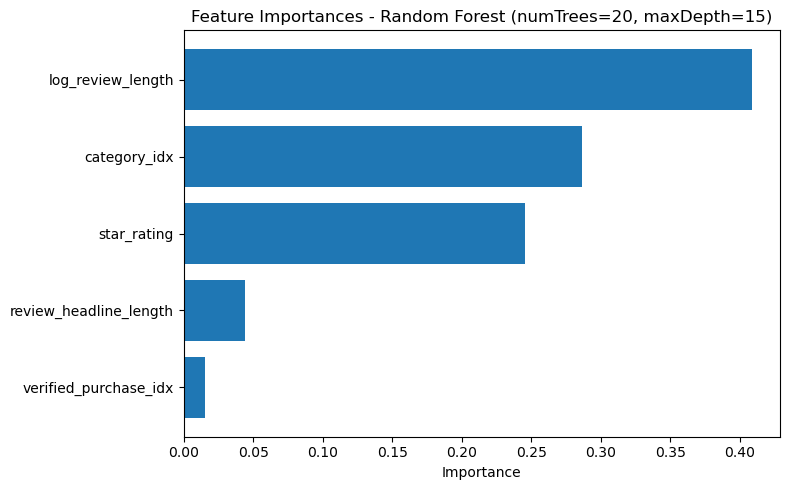

,feature,importance
1,log_review_length,0.408494
4,category_idx,0.286315
0,star_rating,0.245321
2,review_headline_length,0.044301
3,verified_purchase_idx,0.015568


In [24]:
## Feature Importance for Random Forest Model 1 (numTrees=20, maxDepth=15)

importances = model_rf_model1.stages[-1].featureImportances.toArray()

feature_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feature_df["feature"], feature_df["importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importances - Random Forest (numTrees=20, maxDepth=15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feature_df

## 3. Fitting Analysis

In [35]:
fitting_rows = []
for res, description in [
    (lr_results,  "Underfitting"),
    (rf1_results, "Good fit"),
    (rf3_results, "Good fit"),
    (rf2_results, "Underfitting"),
    (rf4_results, "Good fit")  
]:
    fitting_rows.append({
        "Model":      res["Model"],
        "Train AUC":  res["Train AUC"],
        "Val AUC":    res["Val AUC"],
        "Test AUC":   res["Test AUC"],
        "Train F1":   res["Train F1"],
        "Test F1":    res["Test F1"],
        "Description":  description,
    })

fitting_df = pd.DataFrame(fitting_rows).set_index("Model")
fitting_df

,Train AUC,Val AUC,Test AUC,Train F1,Test F1,Description
Model,,,,,,
Logistic Regression (Baseline),0.6623,0.6628,0.6633,0.6364,0.6360,Underfitting
"Random Forest (numTrees=20, maxDepth=15)",0.7096,0.7060,0.7065,0.6871,0.6842,Good fit
"RF (numTrees=50, maxDepth=15)",0.7098,0.7061,0.7068,0.6874,0.6845,Good fit
"RF (numTrees=20, maxDepth=5)",0.6725,0.6722,0.6732,0.6398,0.6391,Underfitting
"RF (numTrees=30, maxDepth=12, sqrt)",0.7025,0.7019,0.7027,0.6828,0.6819,Good fit


### Where does each model fit on the fitting graph?
Both random forest models with maxDepth=15 are considered to have a good fit with a train/test AUC gap under 0.004, indicating no significant overfitting. Logistic regression and random forest with maxDepth=5 both underfit, which shows the decision boundary may not be linear. The logistic regression model shows that a linear boundary may be too simple. The random forest model with numTrees=20 and maxDepth=5 underfits because the trees are too shallow to capture feature interactions. The random forest models with a maxDepth of 12 or 15 appear to have a good fit. 

### Hyperparameter Comparison
Increasing numTrees from 20 to 50 at maxDepth=15 yields a minimal increase. Adding more trees produced diminishing returns given the limited feature space. Increasing maxDepth from 5 to 15 provides the largest performance jump (+0.03 AUC), confirming that tree depth is the most impactful hyperparameter for this dataset. The featureSubsetStrategy="sqrt" variant (Model 4) performs between shallow and deep trees, showing moderate improvement without full depth.

### Which model performs best and why?
The random forest model, where numTrees=50 and maxDepth=15, achieves the highest Test AUC (0.7068) and Test F1 (0.6845), but the difference from the random forest model with numTrees=20 and maxDepth=15 is minimal (+0.0003 AUC). Random forest (numTrees=20, maxDepth=15) is the preferred model. There's equivalent performance at less than half the training time, which matters significantly on the full 50 GB dataset.

### What are the next models you are thinking of for Milestone 4 and why?
- PCA (Principal Component Analysis) with random forest: Reduce the 5-feature space to principal components and retrain RF — required for Milestone 4 dimensionality reduction requirement
- GBT (GBTClassifier): Sequential boosting corrects residual errors from previous trees, expected to outperform RF on tabular data
- SVD (Singular Value Decomposition): can help with compressing it into a smaller and denser set

## 4. Conclusion

### What is the conclusion of the first model?

Using 5 features (`star_rating`, `log_review_length`, `review_headline_length`, `verified_purchase_idx`, `category_idx`), the best Random Forest 
model (numTrees=20, maxDepth=15) achieved a test AUC of 0.7065 and a test F1 of 0.6842. This model outperforms the logistic regression baseline (test AUC 0.6633) by 0.043 AUC points. The consistent train/val/test gap under 0.004 confirms the model generalizes well without overfitting. Structured metadata alone provides a meaningful but limited predictive signal for review helpfulness.

### What can be done to improve it?

1. Text features: Adding vectors or Word2Vec embeddings from `review_body` 
   can be an improvement opportunity because we can see the word meanings.
2. Boosting models: GBT and XGBoost could outperform the random forest by correcting 
   residual errors sequentially rather than averaging independent trees.
3. Dimensionality reduction: PCA on the feature set may reveal latent structure 
   and reduce noise in correlated features.

### How did distributed computing help?
Training on SDSC Expanse with 16 cores in parallel enabled Random Forest training on 
11 million rows in approximately 400 seconds. Without parallelization, building 20 trees 
at maxDepth=15 on this data volume would be impractical on a single core. Spark's 
distributed task execution divided the dataset into partitions processed simultaneously 
across all 16 cores, making iterative hyperparameter comparison feasible within a 
single session.

## 5. Speedup Analysis

We measure the benefit of distributed training by running our representative operation 
(RF (numTrees=20, maxDepth=15)) by training, transforming, and counting on all splits with 1 executor (baseline) versus 15 executors (full allocation) on SDSC Expanse.

In [ ]:
# Baseline Measurement (uses 1 executor). This is used for the speedup analysis comparison.
spark = SparkSession.builder \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.executor.instances", "1") \
    .config("spark.executor.cores", "1") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.sql.parquet.columnarReaderBatchSize", "128") \
    .config("spark.local.dir", f"/expanse/lustre/projects/uci157/{USER}/spark_tmp") \
    .getOrCreate()

In [40]:
import numpy as np

# Recorded times
T_1 = 711.65   # 1  executor (baseline)
T_n = 396.39   # 15 executors (distributed)
n = 15

speedup = T_1 / T_n
efficiency = speedup / n

p_measured = (n * (speedup - 1)) / (speedup * (n - 1))
amdahl_max = 1 / (1 - p_measured) 

print(f"T_1  (1  executor ) : {T_1:.2f} s")
print(f"T_15 (15 executors) : {T_n:.2f} s")
print(f"Speedup             : {speedup:.2f}x")
print(f"Efficiency          : {efficiency:.1%}")
print(f"Est. parallelizable : {p_measured:.1%}")
print(f"Amdahl max speedup  : {amdahl_max:.2f}x")

speedup_table = pd.DataFrame({
    "Executors": [1, n],
    "Time (sec)": [T_1, T_n],
    "Speedup": ["1.00x", f"{speedup:.2f}x"],
    "Efficiency": ["100%", f"{efficiency:.1%}"],
}).set_index("Executors")
print()
print(speedup_table.to_string())

T_1  (1  executor ) : 711.65 s
T_15 (15 executors) : 396.39 s
Speedup             : 1.80x
Efficiency          : 12.0%
Est. parallelizable : 47.5%
Amdahl max speedup  : 1.90x

           Time (sec) Speedup Efficiency
Executors                               
1              711.65   1.00x       100%
15             396.39   1.80x      12.0%


### Speedup Results

| Executors | Time (sec) | Speedup | Efficiency |
|-----------|------------|---------|------------|
| 1         | 711.65     | 1.00x   | 100%       |
| 15        | 396.39     | 1.80x   | 12.0%      |

The measured speedup of 1.80x with 15 executors yields an efficiency of 12.0%. Using Amdahl's Law to estimate the parallelizable fraction:

$$p = \frac{n(S-1)}{S(n-1)} = \frac{15 \times 0.80}{1.80 \times 14} \approx 0.48$$

The theoretical maximum speedup given p=0.48 is:

$$S_{max} = \frac{1}{1-p} = \frac{1}{0.52} \approx 1.92\text{x}$$

Our measured 1.80x reaches 94% of that. The parallelizable fraction is limited to 48% due to two possible factors: Tree growth within each tree contains sequenntial dependencies, which limits perfect parallelization.